In [ ]:
# !pip install -q keras

In [ ]:
# Import required libraries
import os
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sklearn

# Import necessary modules
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from math import sqrt

In [ ]:
# Keras specific
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import to_categorical

In [ ]:
url='https://github.com/prasertcbs/basic-dataset/raw/master/diabetes.csv' # diabetes.csv
df = pd.read_csv(url)
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
target_column = ['Outcome'] # DiabetesPedigreeFunction
predictors = list(set(list(df.columns))-set(target_column))
df[predictors] = df[predictors]/df[predictors].max() # normalization of the predictors via scaling between 0 and 1
df.describe() # displays the summary of the normalized data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,0.226180,0.607510,0.566438,0.207439,0.094326,0.476790,0.194990,0.410381,0.348958
std,0.198210,0.160666,0.158654,0.161134,0.136222,0.117499,0.136913,0.145188,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.032231,0.259259,0.000000
25%,0.058824,0.497487,0.508197,0.000000,0.000000,0.406855,0.100723,0.296296,0.000000
50%,0.176471,0.587940,0.590164,0.232323,0.036052,0.476900,0.153926,0.358025,0.000000
75%,0.352941,0.704774,0.655738,0.323232,0.150414,0.545455,0.258781,0.506173,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# split train-test
X = df[predictors].values
y = df[target_column].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=40)
print(X_train.shape); print(X_test.shape)

(537, 8)
(231, 8)


In [ ]:
# one hot encode outputs
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

count_classes = y_test.shape[1] # y_test(231,2)
print(count_classes)

2


In [ ]:
#deep learning model architecture
model = Sequential() #constructor
model.add(Dense(500, activation='relu', input_dim=8)) #input layer, 8 predictors, ReLU=rectified linear unit(nonlinear)
model.add(Dense(100, activation='relu')) #hidden layers 1
model.add(Dense(50, activation='relu')) #hidden layers 2
model.add(Dense(2, activation='softmax')) #output layer with 2 nodes (nodes depend on output classes)

# Compile the model
model.compile(optimizer='adam', #adam advangtage is don't need to specify the learning rate
              loss='categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# build the model
model.fit(X_train, y_train, epochs=20) #epochs=number of training iterations

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6667 - loss: 0.6647
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6704 - loss: 0.6310 
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6853 - loss: 0.6105 
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7039 - loss: 0.5894
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7337 - loss: 0.5618 
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7430 - loss: 0.5321 
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7579 - loss: 0.5117 
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7598 - loss: 0.4965 
Epoch 9/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7728 - loss: 0.4797 
Epoch 10/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7784 - loss: 0.4782 
Epoch 11/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7858 - loss: 0.4665 
Epoch 12/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.

In [ ]:
pred_train= model.predict(X_train)
scores = model.evaluate(X_train, y_train, verbose=0)
print('Accuracy on training data: {}% \n Error on training data: {}'.format(scores[1], 1 - scores[1]))

pred_test= model.predict(X_test)
scores2 = model.evaluate(X_test, y_test, verbose=0)
print('Accuracy on test data: {}% \n Error on test data: {}'.format(scores2[1], 1 - scores2[1]))

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Accuracy on training data: 0.8044692873954773% 
 Error on training data: 0.1955307126045227
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Accuracy on test data: 0.7575757503509521% 
 Error on test data: 0.24242424964904785


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


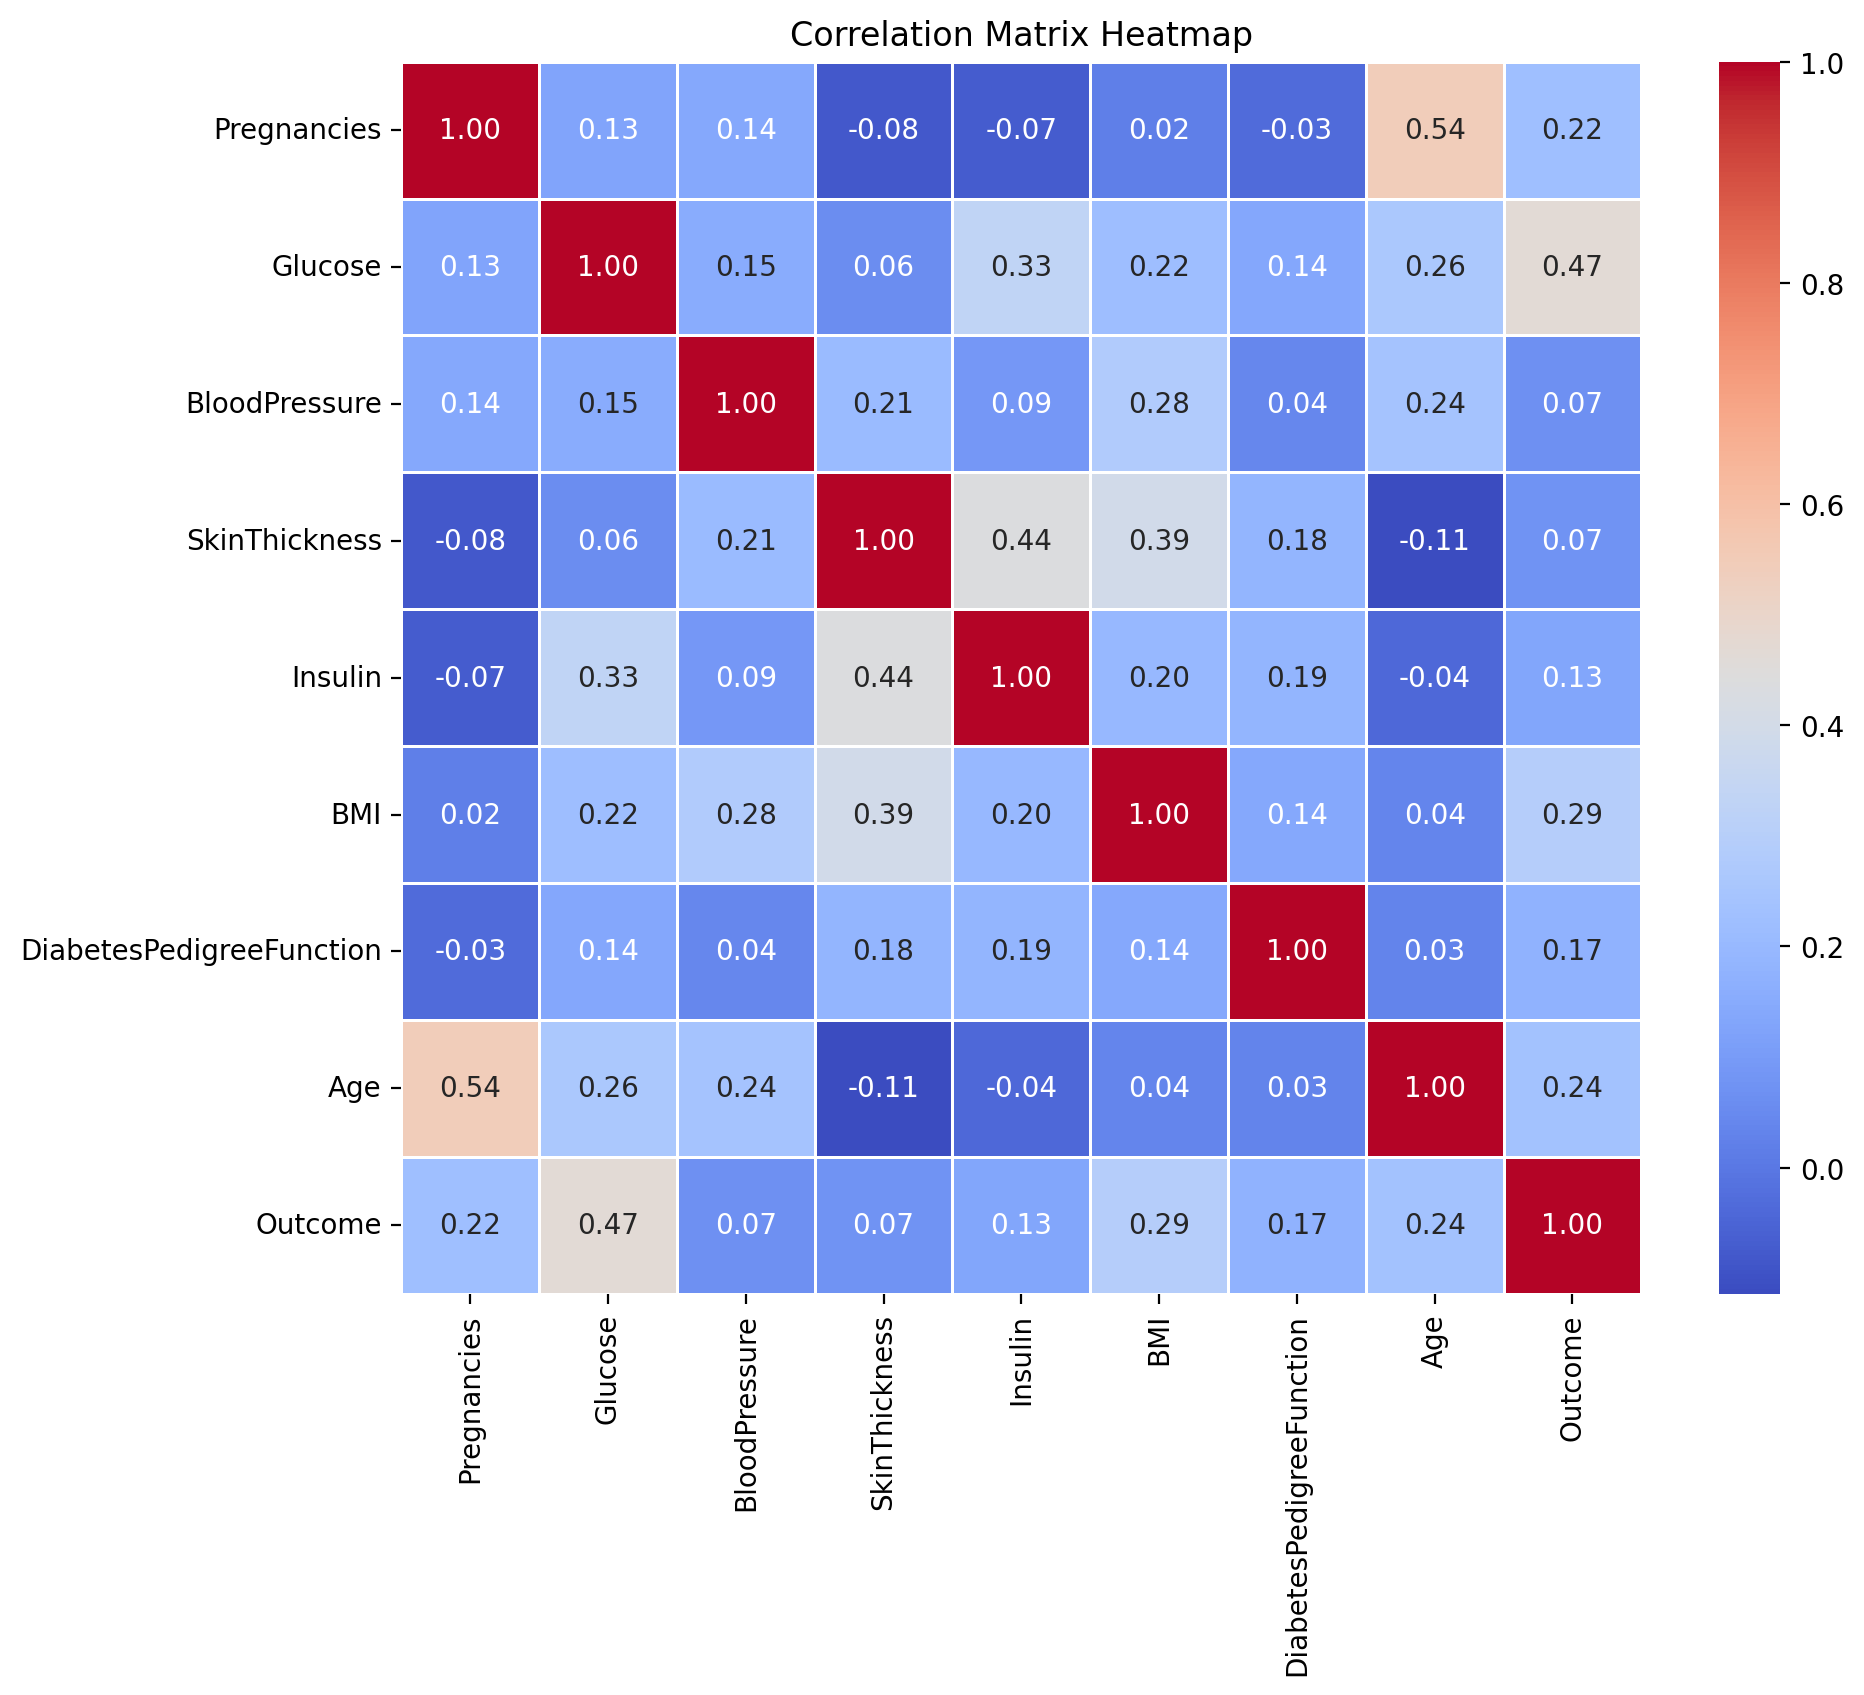

In [ ]:
correlation_matrix = df.corr()
display(correlation_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

### Feature importance

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Need original y for RandomForestClassifier, not one-hot encoded
# The original 'y' variable is already in the kernel state.

# Initialize and train a RandomForestClassifier
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train.argmax(axis=1)) # y_train is one-hot encoded, so convert back to class labels

# Get feature importances
feature_importances = pd.Series(model_rf.feature_importances_, index=predictors)

# Sort and get top 5 features
top_5_features = feature_importances.nlargest(5).index.tolist()

print("Top 5 features based on RandomForestClassifier importance:")
print(top_5_features)

Top 5 features based on RandomForestClassifier importance:
['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction', 'Pregnancies']


In [ ]:
# The current X_train and X_test are already numpy arrays, and their original indices are lost during train_test_split.
# To correctly select features from X_train and X_test, we need to apply the feature selection BEFORE the split, or store the indices.
# Let's recreate X_train and X_test using only the top 5 features from the original df and then split again.

X_top5 = df[top_5_features].values
y_original = df[target_column].values # Use the original y, which was not one-hot encoded initially

X_train_top5, X_test_top5, y_train_top5, y_test_top5 = train_test_split(X_top5, y_original, test_size=0.30, random_state=40)

# One-hot encode outputs for the new model
y_train_top5_onehot = to_categorical(y_train_top5)
y_test_top5_onehot = to_categorical(y_test_top5)

print(X_train_top5.shape)
print(X_test_top5.shape)

(537, 5)
(231, 5)


In [ ]:
# Deep learning model architecture with 5 input features
model_top5 = Sequential()
model_top5.add(Dense(500, activation='relu', input_dim=len(top_5_features))) # input_dim set to 5
model_top5.add(Dense(100, activation='relu'))
model_top5.add(Dense(50, activation='relu'))
model_top5.add(Dense(2, activation='softmax')) # Output layer for 2 classes

# Compile the new model
model_top5.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Train the new model with top 5 features
history_top5 = model_top5.fit(X_train_top5, y_train_top5_onehot, epochs=20, verbose=0) # verbose=0 to reduce output verbosity

# Evaluate the new model
scores_top5_train = model_top5.evaluate(X_train_top5, y_train_top5_onehot, verbose=0)
print('Accuracy on training data (top 5 features): {}%'.format(scores_top5_train[1]))

scores_top5_test = model_top5.evaluate(X_test_top5, y_test_top5_onehot, verbose=0)
print('Accuracy on test data (top 5 features): {}%'.format(scores_top5_test[1]))

Accuracy on training data (top 5 features): 0.774674117565155%
Accuracy on test data (top 5 features): 0.7705627679824829%


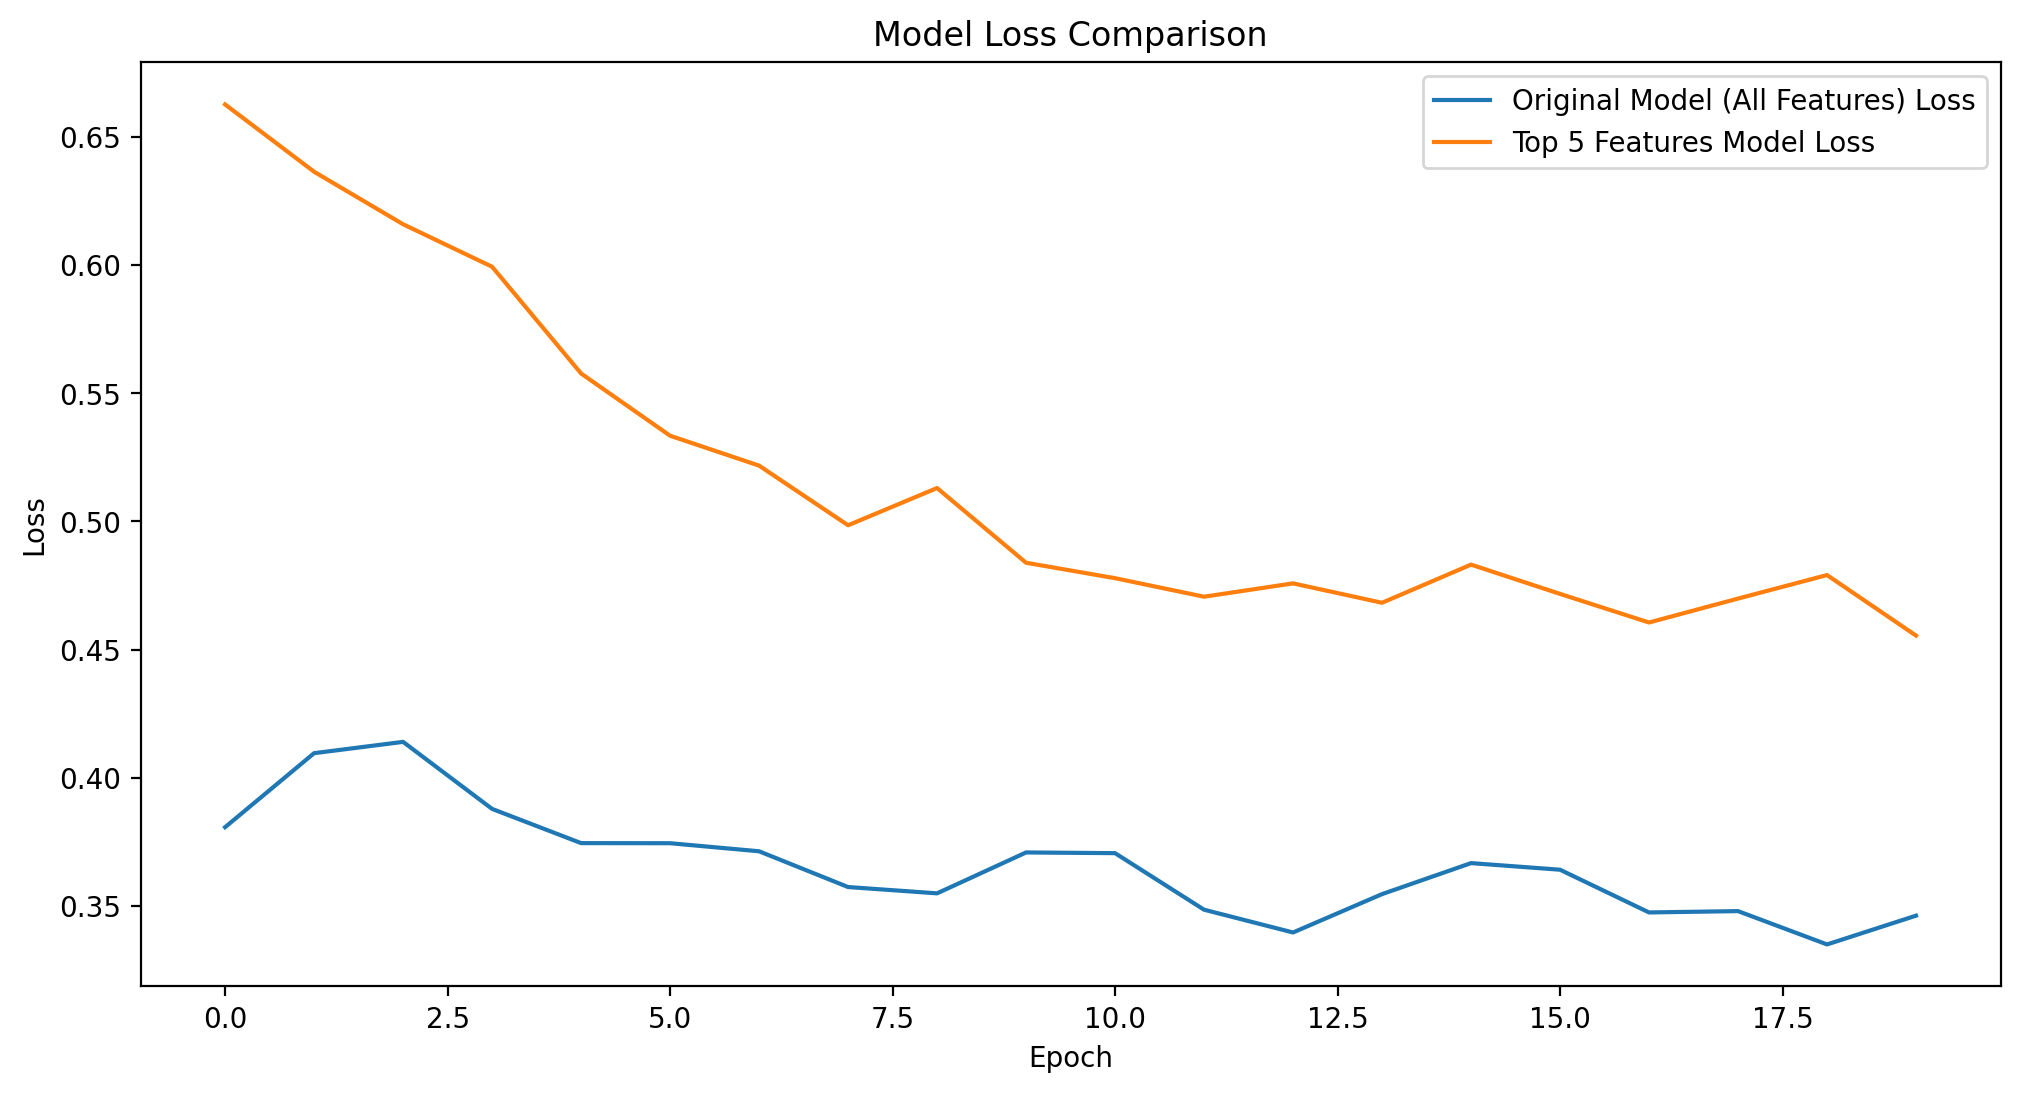

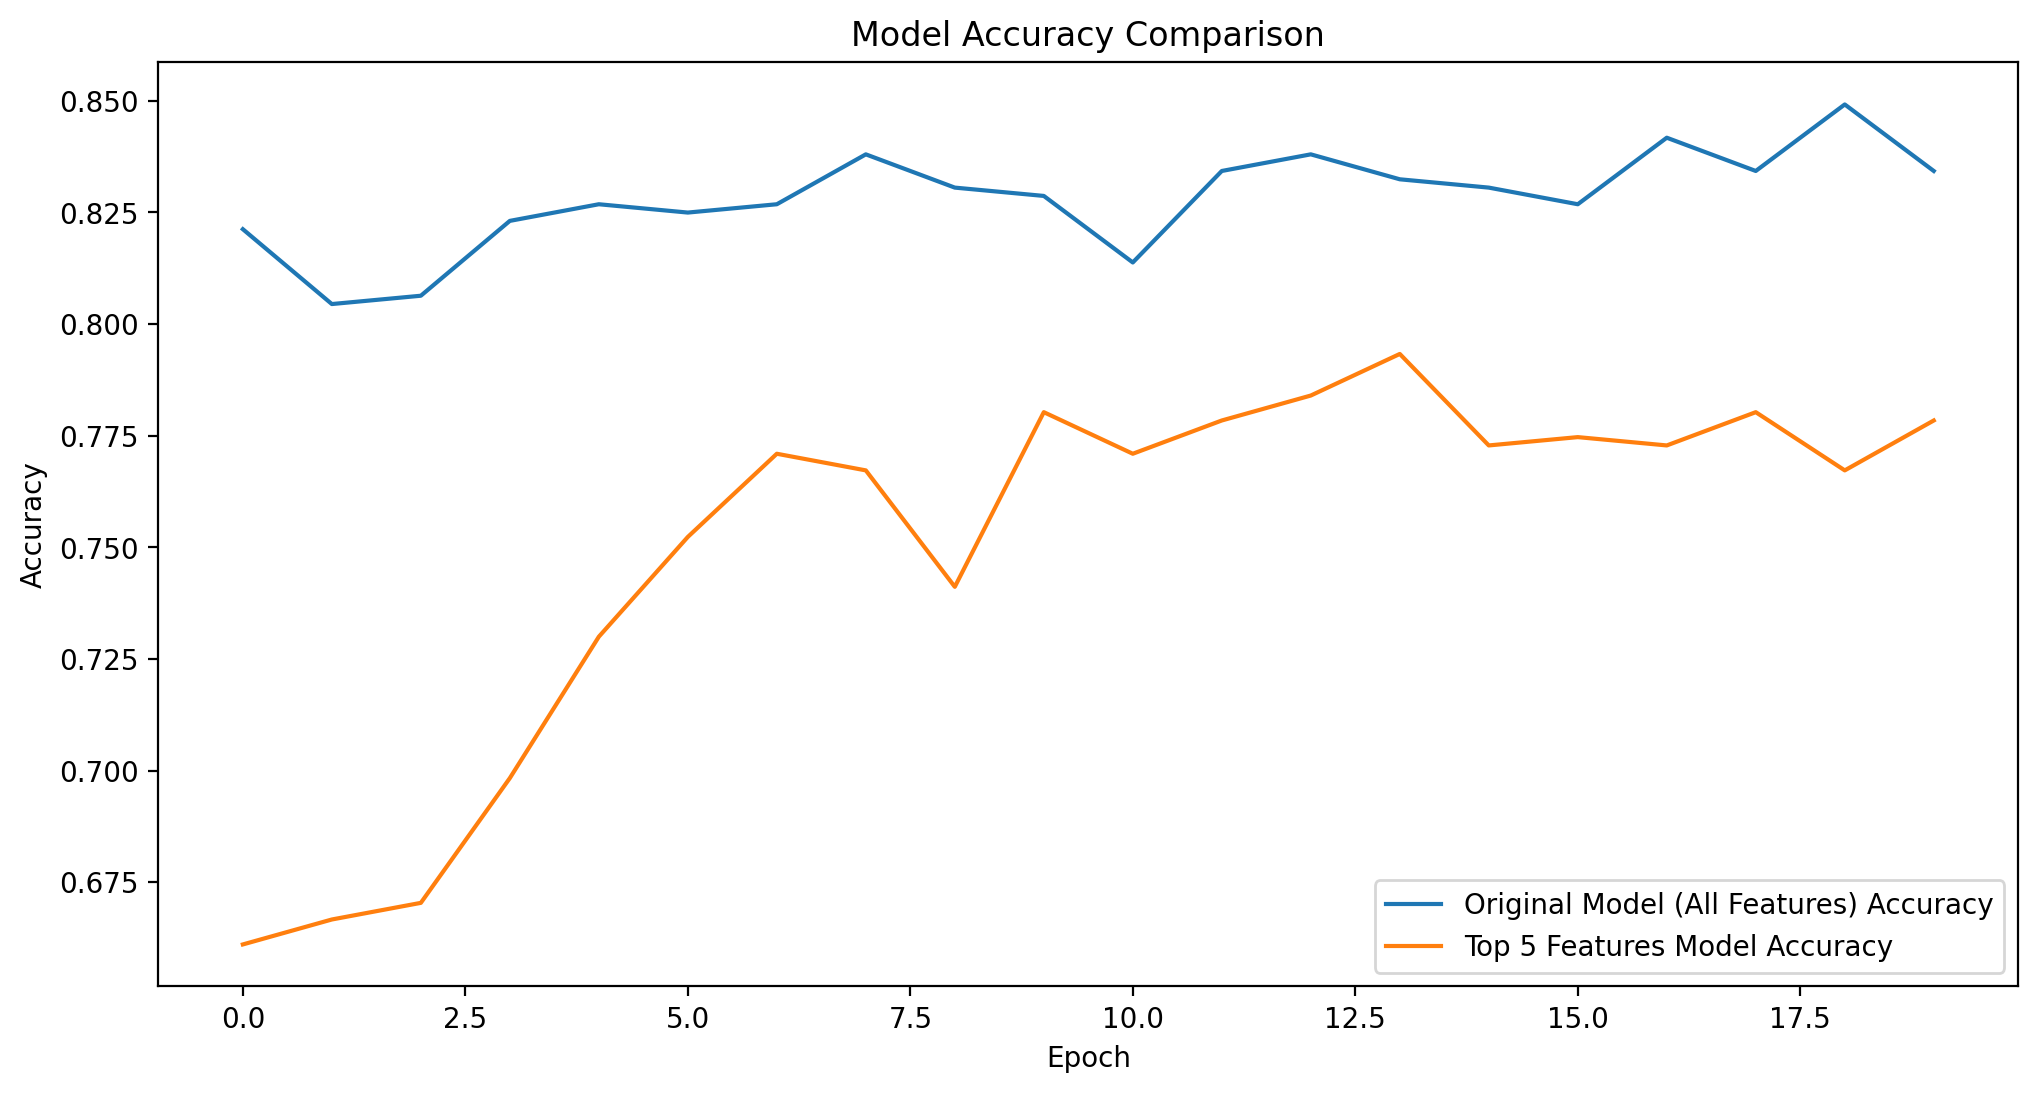

In [ ]:
# Plot the learning curves for both models

# Extract loss history for the original model (assuming it was stored in a variable, if not, we need to re-run fit with history)
# For simplicity, let's assume `history` variable was not saved in the earlier `model.fit`. I will re-run the previous model fit with history.

# Re-train the original model to capture history
history_original = model.fit(X_train, y_train, epochs=20, verbose=0)

plt.figure(figsize=(12, 6))

# Plot original model loss
plt.plot(history_original.history['loss'], label='Original Model (All Features) Loss')
# Plot new model loss
plt.plot(history_top5.history['loss'], label='Top 5 Features Model Loss')

plt.title('Model Loss Comparison')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()

plt.figure(figsize=(12, 6))

# Plot original model accuracy
plt.plot(history_original.history['accuracy'], label='Original Model (All Features) Accuracy')
# Plot new model accuracy
plt.plot(history_top5.history['accuracy'], label='Top 5 Features Model Accuracy')

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.show()